In [1]:
!pip install pandas scikit-learn matplotlib -q

In [2]:
import os
import zipfile
import re
from collections import Counter
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from IPython.display import display, HTML
import kagglehub


In [3]:
path = kagglehub.dataset_download("pariza/bbc-news-summary")

print("Path to dataset files:", path)

100%|██████████| 8.91M/8.91M [00:00<00:00, 66.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2


In [4]:

extract_path = path


print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
for root, dirs, files_list in os.walk(path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files_list[:5])
    print("-" * 60)

/root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2
Folders: ['bbc news summary', 'BBC News Summary']
Files: []
------------------------------------------------------------
/root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2/bbc news summary
Folders: ['BBC News Summary']
Files: []
------------------------------------------------------------
/root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2/bbc news summary/BBC News Summary
Folders: ['News Articles', 'Summaries']
Files: []
------------------------------------------------------------
/root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2/bbc news summary/BBC News Summary/News Articles
Folders: ['entertainment', 'politics', 'tech', 'sport', 'business']
Files: []
------------------------------------------------------------
/root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2/bbc news summary/BBC News Summary/News Articles/entertainment
Folders: []
Files: ['177.txt', '

In [6]:
import os
import pandas as pd

base_path = "/root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2"

articles_path = None
summaries_path = None

for root, dirs, _ in os.walk(base_path):
    if "News Articles" in dirs and "Summaries" in dirs:
        articles_path = os.path.join(root, "News Articles")
        summaries_path = os.path.join(root, "Summaries")
        break

if not articles_path or not summaries_path:
    raise FileNotFoundError(f"'News Articles' ve 'Summaries' klasörleri {base_path} dizini içinde bulunamadı.")

print("Bulunan Articles Yolu:", articles_path)
print("Bulunan Summaries Yolu:", summaries_path)

data = []
categories = sorted(os.listdir(articles_path))

for category in categories:
    article_category_path = os.path.join(articles_path, category)
    summary_category_path = os.path.join(summaries_path, category)

    for filename in sorted(os.listdir(article_category_path)):
        article_file = os.path.join(article_category_path, filename)
        summary_file = os.path.join(summary_category_path, filename)

        if not os.path.exists(summary_file):
            continue

        with open(article_file, "r", encoding="latin-1") as f:
            article_text = f.read()

        with open(summary_file, "r", encoding="latin-1") as f:
            reference_summary = f.read()

        data.append({
            "category": category,
            "filename": filename,
            "article": article_text,
            "reference_summary": reference_summary
        })

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
display(df.head())

Bulunan Articles Yolu: /root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2/bbc news summary/BBC News Summary/News Articles
Bulunan Summaries Yolu: /root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2/bbc news summary/BBC News Summary/Summaries
Dataset shape: (2225, 4)


,category,filename,article,reference_summary
0,business,001.txt,Ad sales boost Time Warner profit\n\nQuarterly...,TimeWarner said fourth quarter sales rose 2% t...
1,business,002.txt,Dollar gains on Greenspan speech\n\nThe dollar...,The dollar has hit its highest level against t...
2,business,003.txt,Yukos unit buyer faces loan claim\n\nThe owner...,Yukos' owner Menatep Group says it will ask Ro...
3,business,004.txt,High fuel prices hit BA's profits\n\nBritish A...,"Rod Eddington, BA's chief executive, said the ..."
4,business,005.txt,Pernod takeover talk lifts Domecq\n\nShares in...,Pernod has reduced the debt it took on to fund...


category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


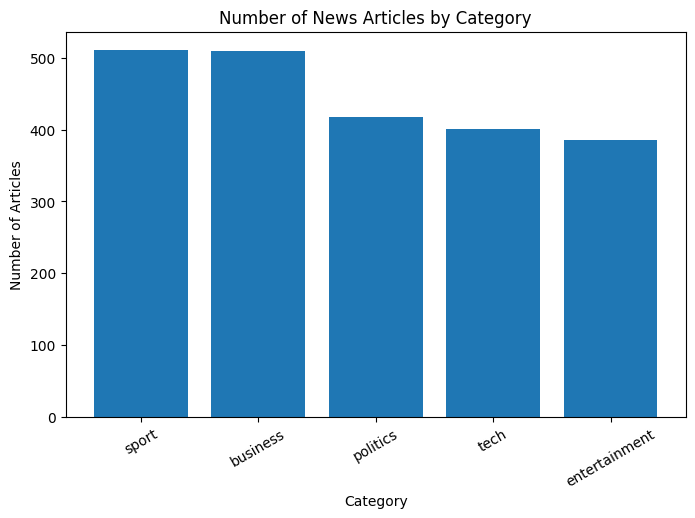

In [7]:
category_counts = df["category"].value_counts()
print(category_counts)

plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values)
plt.title("Number of News Articles by Category")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=30)
plt.show()

In [8]:
def clean_text(text):
    text = str(text)
    text = text.replace("Â£", "£")
    text = text.replace("Â", "")
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

for col in ["article", "reference_summary"]:
    df[col] = df[col].apply(clean_text)

df = df.dropna(subset=["article", "reference_summary"]).drop_duplicates(subset=["article", "reference_summary"])

print("Dataset shape after cleaning:", df.shape)
df.head()

Dataset shape after cleaning: (2125, 4)


,category,filename,article,reference_summary
0,business,001.txt,Ad sales boost Time Warner profit Quarterly pr...,TimeWarner said fourth quarter sales rose 2% t...
1,business,002.txt,Dollar gains on Greenspan speech The dollar ha...,The dollar has hit its highest level against t...
2,business,003.txt,Yukos unit buyer faces loan claim The owners o...,Yukos' owner Menatep Group says it will ask Ro...
3,business,004.txt,High fuel prices hit BA's profits British Airw...,"Rod Eddington, BA's chief executive, said the ..."
4,business,005.txt,Pernod takeover talk lifts Domecq Shares in UK...,Pernod has reduced the debt it took on to fund...


In [9]:
def split_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+', str(text))
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    return sentences

sample_article = df.iloc[0]["article"]
sample_sentences = split_sentences(sample_article)

print("Number of sentences:", len(sample_sentences))
print("\nFirst 5 sentences:")
for i, sentence in enumerate(sample_sentences[:5], 1):
    print(i, sentence)

Number of sentences: 20

First 5 sentences:
1 Ad sales boost Time Warner profit Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.
2 The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales.
3 TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.
4 Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.
5 Time Warner said on Friday that it now owns 8% of search-engine Google.


In [10]:
import re
from collections import Counter

def calculate_word_frequencies(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())

    words = [
        word for word in words
        if word not in ENGLISH_STOP_WORDS and len(word) > 2
    ]

    word_frequencies = Counter(words)

    if not word_frequencies:
        return {}

    max_frequency = max(word_frequencies.values())

    normalized_frequencies = {
        word: freq / max_frequency
        for word, freq in word_frequencies.items()
    }

    return normalized_frequencies

word_frequencies = calculate_word_frequencies(sample_article)

print("Number of important words:", len(word_frequencies))
print("Top 10 words:")
for word, freq in sorted(word_frequencies.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(word, round(freq, 3))

Number of important words: 157
Top 10 words:
timewarner 1.0
aol 1.0
profit 0.714
profits 0.714
said 0.714
sales 0.571
warner 0.571
year 0.571
internet 0.571
time 0.429


In [11]:
def score_sentences_frequency(sentences, word_frequencies):
    sentence_scores = {}

    for sentence in sentences:
        sentence_words = re.findall(r'\b[a-zA-Z]+\b', sentence.lower())
        score = 0

        for word in sentence_words:
            if word in word_frequencies:
                score += word_frequencies[word]

        sentence_scores[sentence] = score

    return sentence_scores

sentence_scores = score_sentences_frequency(sample_sentences, word_frequencies)

print("Sentence scores:")
for i, sentence in enumerate(sample_sentences, 1):
    print(i, "Score:", round(sentence_scores[sentence], 2))
    print(sentence)
    print("-" * 80)

Sentence scores:
1 Score: 5.86
Ad sales boost Time Warner profit Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.
--------------------------------------------------------------------------------
2 Score: 3.71
The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales.
--------------------------------------------------------------------------------
3 Score: 3.43
TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.
--------------------------------------------------------------------------------
4 Score: 3.86
Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.
--------------------------------------------------------------------------------
5 Score: 2.57
Time Warner said on Friday that it now owns 8% of search-engine Google.
--------------------------

In [12]:
def generate_frequency_summary(text, num_sentences=3):
    sentences = split_sentences(text)

    if len(sentences) == 0:
        return ""

    if len(sentences) <= num_sentences:
        return " ".join(sentences)

    word_frequencies = calculate_word_frequencies(text)
    sentence_scores = score_sentences_frequency(sentences, word_frequencies)

    selected_sentences = sorted(
        sentence_scores,
        key=sentence_scores.get,
        reverse=True
    )[:num_sentences]

    final_summary = [
        sentence for sentence in sentences
        if sentence in selected_sentences
    ]

    return " ".join(final_summary)

frequency_summary = generate_frequency_summary(sample_article, num_sentences=3)
reference_summary = df.iloc[0]["reference_summary"]

print("REFERENCE SUMMARY:", reference_summary)
print("FREQUENCY-BASED GENERATED SUMMARY:", frequency_summary)

REFERENCE SUMMARY: TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.For 2005, TimeWarner is projecting operating earnings growth of around 5%, and also expects higher revenue and wider profit margins.It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters.Time Warner's fourth quarter profits were slightly better than analysts' expectations.
FREQUENCY-BASED GENERATED SUMMARY: Ad sales boost Time Warner profit Quarterly p

In [13]:
def generate_tfidf_summary(text, num_sentences=3):
    sentences = split_sentences(text)

    if len(sentences) == 0:
        return ""

    if len(sentences) <= num_sentences:
        return " ".join(sentences)

    vectorizer = TfidfVectorizer(
        stop_words="english",
        lowercase=True
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(sentences)
    except ValueError:
        return " ".join(sentences[:num_sentences])

    sentence_scores = np.asarray(tfidf_matrix.sum(axis=1)).flatten()

    top_sentence_indices = sentence_scores.argsort()[-num_sentences:][::-1]
    top_sentence_indices = sorted(top_sentence_indices)

    selected_sentences = [sentences[i] for i in top_sentence_indices]

    return " ".join(selected_sentences)

tfidf_summary = generate_tfidf_summary(sample_article, num_sentences=3)

print("REFERENCE SUMMARY:", reference_summary)
print("TF-IDF GENERATED SUMMARY:", tfidf_summary)

REFERENCE SUMMARY: TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.For 2005, TimeWarner is projecting operating earnings growth of around 5%, and also expects higher revenue and wider profit margins.It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters.Time Warner's fourth quarter profits were slightly better than analysts' expectations.
TF-IDF GENERATED SUMMARY: Ad sales boost Time Warner profit Quarterly profits at

In [14]:
import re
import numpy as np
import nltk
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

def generate_hybrid_summary(text, num_sentences=None):
    sentences = split_sentences(text)
    if not sentences:
        return ""

    N = len(sentences)
    if N <= 1:
        return " ".join(sentences)

    doc_words = re.findall(r'\b\w+\b', text.lower())
    total_words_in_doc = len(doc_words)
    word_freq = Counter(doc_words)

    sentence_tfs = []
    for s in sentences:
        s_words = re.findall(r'\b\w+\b', s.lower())
        # Cümledeki kelimelerin TF toplamı
        s_tf = sum([(word_freq[w] / total_words_in_doc) for w in s_words]) if total_words_in_doc > 0 else 0
        sentence_tfs.append(s_tf)

    max_tf = max(sentence_tfs) if sentence_tfs else 1
    if max_tf == 0: max_tf = 1

    # 7. Sentence Similarity (Cümle Benzerliği) için Vektörleştirme (Bag of Words)
    vectorizer = CountVectorizer()
    try:
        bow_matrix = vectorizer.fit_transform(sentences).toarray()
        first_sentence_vec = bow_matrix[0].reshape(1, -1)
        last_sentence_vec = bow_matrix[-1].reshape(1, -1)
    except ValueError:
        bow_matrix = None

    longest_sentence_len = max([len(re.findall(r'\b\w+\b', s)) for s in sentences])
    if longest_sentence_len == 0: longest_sentence_len = 1

    sentence_scores = []

    # Her bir cümle için makaledeki 7 metriğin hesaplanması
    for i, s in enumerate(sentences):
        s_words = re.findall(r'\b\w+\b', s)
        s_len = len(s_words)
        if s_len == 0:
            sentence_scores.append(0)
            continue

        # 1. Term Frequency (tf)
        tf = sentence_tfs[i]

        # 2. Term Weighting (tw)
        tw = tf / max_tf

        # 3. Numerical Data (nd)
        num_count = len(re.findall(r'\d+', s))
        nd = num_count / s_len

        # 4. Sentence Length (sl)
        sl = s_len / longest_sentence_len

        # 5. Proper Nouns (pn)
        tagged = nltk.pos_tag(s_words)
        pn_count = len([word for word, tag in tagged if tag in ('NNP', 'NNPS')])
        pn = pn_count / s_len

        # 6. Sentence Location (slo)
        slo = (N - i) / N

        # 7. Sentence Similarity (ss)
        ss = 0
        if bow_matrix is not None:
            curr_vec = bow_matrix[i].reshape(1, -1)
            sim_first = cosine_similarity(curr_vec, first_sentence_vec)[0][0]
            sim_last = cosine_similarity(curr_vec, last_sentence_vec)[0][0]
            ss = (sim_first + sim_last) / 2

        total_score = tf + tw + nd + sl + pn + slo + ss
        sentence_scores.append(total_score)

    avg_score = np.mean(sentence_scores)

    system_summary = []
    for i, s in enumerate(sentences):
        if sentence_scores[i] > avg_score:
            system_summary.append(s)

    return " ".join(system_summary)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [15]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
hybrid_summary = generate_hybrid_summary(sample_article)

result_df = pd.DataFrame({
    "Bölüm": [
        "Orijinal Haber Metni",
        "Referans Özet",
        "Frequency-Based Özet",
        "TF-IDF Özet",
        "Hybrid Model"
    ],
    "Açıklama": [
        "Veri setindeki orijinal uzun haber metni",
        "Veri setindeki hazır insan/referans özeti",
        "Kelime frekansına dayalı extractive yöntemle üretilen özet",
        "TF-IDF tabanlı extractive yöntemle üretilen özet",
        "Makalede önerilen 7 metrikli ortalama skor tabanlı yöntem"
    ],
    "Metin": [
        sample_article[:700] + "...",
        reference_summary,
        frequency_summary,
        tfidf_summary,
        hybrid_summary
    ]
})

html_table = result_df.to_html(escape=False, index=False, justify="left")
html_table = html_table.replace(
    '<table border="1" class="dataframe">',
    '<table style="border-collapse: collapse; width:100%; font-family: Arial; font-size:14px; background-color:white; color:black;" border="1">'
).replace(
    '<th>',
    '<th style="background-color:#eaeaea; color:black; padding:10px; text-align:left;">'
).replace(
    '<td>',
    '<td style="background-color:white; color:black; padding:10px; vertical-align:top; text-align:left;">'
)

display(HTML(html_table))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Bölüm,Açıklama,Metin
Orijinal Haber Metni,Veri setindeki orijinal uzun haber metni,"Ad sales boost Time Warner profit Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier. The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL. Time Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in ..."
Referans Özet,Veri setindeki hazır insan/referans özeti,"TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.For 2005, TimeWarner is projecting operating earnings growth of around 5%, and also expects higher revenue and wider profit margins.It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters.Time Warner's fourth quarter profits were slightly better than analysts' expectations."
Frequency-Based Özet,Kelime frekansına dayalı extractive yöntemle üretilen özet,"Ad sales boost Time Warner profit Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier. It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try to sign up AOL's existing customers for high-speed broadband. But its film division saw profits slump 27% to $284m, helped by box-office flops Alexander and Catwoman, a sharp contrast to year-earlier, when the third and final film in the Lord of the Rings trilogy boosted results."
TF-IDF Özet,TF-IDF tabanlı extractive yöntemle üretilen özet,"Ad sales boost Time Warner profit Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier. But its film division saw profits slump 27% to $284m, helped by box-office flops Alexander and Catwoman, a sharp contrast to year-earlier, when the third and final film in the Lord of the Rings trilogy boosted results. ""Our financial performance was strong, meeting or exceeding all of our full-year objectives and greatly enhancing our flexibility,"" chairman and chief executive Richard Parsons said."
Hybrid Model,Makalede önerilen 7 metrikli ortalama skor tabanlı yöntem,"Ad sales boost Time Warner profit Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier. The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL. It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try to sign up AOL's existing customers for high-speed broadband. TimeWarner also has to restate 2000 and 2003 results following a probe by the US Securities Exchange Commission (SEC), which is close to concluding. But its film division saw profits slump 27% to $284m, helped by box-office flops Alexander and Catwoman, a sharp contrast to year-earlier, when the 

In [16]:
def tokenize_words(text):
    return re.findall(r'\w+', str(text).lower())


def get_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]


def rouge_n_recall(system_summary, reference_summary, n=1):
    system_tokens = tokenize_words(system_summary)
    reference_tokens = tokenize_words(reference_summary)

    system_ngrams = Counter(get_ngrams(system_tokens, n))
    reference_ngrams = Counter(get_ngrams(reference_tokens, n))

    if sum(reference_ngrams.values()) == 0:
        return 0.0

    overlap = sum((system_ngrams & reference_ngrams).values())
    return overlap / sum(reference_ngrams.values())


def lcs_length(x, y):
    # Dynamic programming for Longest Common Subsequence
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if x[i - 1] == y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    return dp[m][n]


def rouge_l_f1(system_summary, reference_summary):
    system_tokens = tokenize_words(system_summary)
    reference_tokens = tokenize_words(reference_summary)

    if len(system_tokens) == 0 or len(reference_tokens) == 0:
        return 0.0

    lcs = lcs_length(system_tokens, reference_tokens)
    precision = lcs / len(system_tokens)
    recall = lcs / len(reference_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)


def get_skip_bigrams(tokens):
    return list(combinations(tokens, 2))


def rouge_s_f1(system_summary, reference_summary):
    system_tokens = tokenize_words(system_summary)
    reference_tokens = tokenize_words(reference_summary)

    system_skip = Counter(get_skip_bigrams(system_tokens))
    reference_skip = Counter(get_skip_bigrams(reference_tokens))

    if sum(system_skip.values()) == 0 or sum(reference_skip.values()) == 0:
        return 0.0

    overlap = sum((system_skip & reference_skip).values())
    precision = overlap / sum(system_skip.values())
    recall = overlap / sum(reference_skip.values())

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

In [17]:
def normalize_sentence(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r'[^a-z0-9\s]', '', sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    return sentence


def sentence_precision_recall_f1(system_summary, reference_summary):
    system_sentences = set(normalize_sentence(s) for s in split_sentences(system_summary))
    reference_sentences = set(normalize_sentence(s) for s in split_sentences(reference_summary))

    system_sentences = {s for s in system_sentences if s}
    reference_sentences = {s for s in reference_sentences if s}

    if len(system_sentences) == 0 or len(reference_sentences) == 0:
        return 0.0, 0.0, 0.0

    matches = len(system_sentences & reference_sentences)
    precision = matches / len(system_sentences)
    recall = matches / len(reference_sentences)

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1

In [18]:
def evaluate_summarizer(df, summarizer_func, method_name, sample_size=500, num_sentences=3, random_state=42):
    sample_size = min(sample_size, len(df))
    test_sample = df.sample(sample_size, random_state=random_state)

    rows = []
    predictions = []
    references = []

    for _, row in test_sample.iterrows():
        article = row["article"]
        reference = row["reference_summary"]
        prediction = summarizer_func(article, num_sentences=num_sentences)

        predictions.append(prediction)
        references.append(reference)

        precision, recall, f1 = sentence_precision_recall_f1(prediction, reference)

        rows.append({
            "method": method_name,
            "category": row["category"],
            "filename": row["filename"],
            "ROUGE-1": rouge_n_recall(prediction, reference, n=1),
            "ROUGE-2": rouge_n_recall(prediction, reference, n=2),
            "ROUGE-3": rouge_n_recall(prediction, reference, n=3),
            "ROUGE-4": rouge_n_recall(prediction, reference, n=4),
            "ROUGE-L": rouge_l_f1(prediction, reference),
            "ROUGE-S": rouge_s_f1(prediction, reference),
            "Sentence Precision": precision,
            "Sentence Recall": recall,
            "Sentence F1": f1,
            "prediction": prediction,
            "reference": reference
        })

    detail_df = pd.DataFrame(rows)

    metric_columns = [
        "ROUGE-1", "ROUGE-2", "ROUGE-3", "ROUGE-4",
        "ROUGE-L", "ROUGE-S",
        "Sentence Precision", "Sentence Recall", "Sentence F1"
    ]

    average_scores = detail_df[metric_columns].mean().to_dict()
    average_scores["Method"] = method_name
    average_scores["Sample Size"] = sample_size

    return average_scores, detail_df

In [19]:
from collections import Counter
from itertools import combinations
import re

def tokenize_words(text):
    return re.findall(r'\b\w+\b', str(text).lower())


def get_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]


def rouge_n_recall(system_summary, reference_summary, n=1):
    system_tokens = tokenize_words(system_summary)
    reference_tokens = tokenize_words(reference_summary)

    system_ngrams = Counter(get_ngrams(system_tokens, n))
    reference_ngrams = Counter(get_ngrams(reference_tokens, n))

    if sum(reference_ngrams.values()) == 0:
        return 0.0

    overlap = sum((system_ngrams & reference_ngrams).values())
    return overlap / sum(reference_ngrams.values())


def lcs_length(x, y):
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if x[i - 1] == y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    return dp[m][n]


def rouge_l_f1(system_summary, reference_summary):
    system_tokens = tokenize_words(system_summary)
    reference_tokens = tokenize_words(reference_summary)

    if len(system_tokens) == 0 or len(reference_tokens) == 0:
        return 0.0

    lcs = lcs_length(system_tokens, reference_tokens)
    precision = lcs / len(system_tokens)
    recall = lcs / len(reference_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)


def get_skip_bigrams(tokens):
    return list(combinations(tokens, 2))


def rouge_s_f1(system_summary, reference_summary):
    system_tokens = tokenize_words(system_summary)
    reference_tokens = tokenize_words(reference_summary)

    system_skip = Counter(get_skip_bigrams(system_tokens))
    reference_skip = Counter(get_skip_bigrams(reference_tokens))

    if sum(system_skip.values()) == 0 or sum(reference_skip.values()) == 0:
        return 0.0

    overlap = sum((system_skip & reference_skip).values())
    precision = overlap / sum(system_skip.values())
    recall = overlap / sum(reference_skip.values())

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

print("Metric functions fixed successfully!")

Metric functions fixed successfully!


In [20]:
SAMPLE_SIZE = 500
NUM_SENTENCES = 3

freq_scores, freq_detail = evaluate_summarizer(
    df,
    generate_frequency_summary,
    "Frequency-Based",
    sample_size=SAMPLE_SIZE,
    num_sentences=NUM_SENTENCES
)

tfidf_scores, tfidf_detail = evaluate_summarizer(
    df,
    generate_tfidf_summary,
    "TF-IDF",
    sample_size=SAMPLE_SIZE,
    num_sentences=NUM_SENTENCES
)

hybrid_scores, hybrid_detail = evaluate_summarizer(
    df,
    generate_hybrid_summary,
    "Hybrid",
    sample_size=SAMPLE_SIZE,
    num_sentences=NUM_SENTENCES
)

comparison_results = pd.DataFrame([freq_scores, tfidf_scores, hybrid_scores])
comparison_results = comparison_results[[
    "Method", "Sample Size", "ROUGE-1", "ROUGE-2", "ROUGE-3", "ROUGE-4",
    "ROUGE-L", "ROUGE-S"
]]

comparison_results

,Method,Sample Size,ROUGE-1,ROUGE-2,ROUGE-3,ROUGE-4,ROUGE-L,ROUGE-S
0,Frequency-Based,500,0.496809,0.423666,0.403418,0.389631,0.428066,0.279692
1,TF-IDF,500,0.444002,0.337891,0.315762,0.304418,0.370375,0.223025
2,Hybrid,500,0.791806,0.684425,0.650591,0.627187,0.433448,0.375995


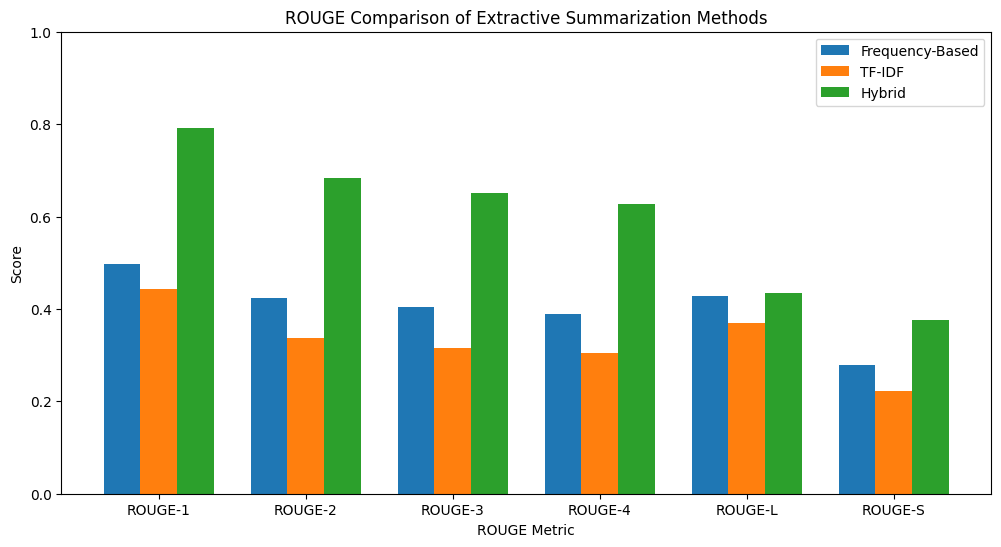

In [21]:
rouge_metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-3", "ROUGE-4", "ROUGE-L", "ROUGE-S"]

x = np.arange(len(rouge_metrics))
width = 0.25

plt.figure(figsize=(12, 6))

for i, method in enumerate(comparison_results["Method"]):
    values = comparison_results.loc[comparison_results["Method"] == method, rouge_metrics].values.flatten()
    plt.bar(x + (i - 1) * width, values, width, label=method)

plt.xticks(x, rouge_metrics)
plt.xlabel("ROUGE Metric")
plt.ylabel("Score")
plt.title("ROUGE Comparison of Extractive Summarization Methods")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [22]:
def evaluate_by_category(df, summarizer_func, method_name, num_sentences=3):
    category_rows = []

    for category, group in df.groupby("category"):
        scores, _ = evaluate_summarizer(
            group,
            summarizer_func,
            method_name=f"{method_name} - {category}",
            sample_size=len(group),
            num_sentences=num_sentences,
            random_state=42
        )
        scores["Category"] = category
        category_rows.append(scores)

    category_df = pd.DataFrame(category_rows)
    return category_df[[
        "Category", "Sample Size", "ROUGE-1", "ROUGE-2", "ROUGE-3", "ROUGE-4", "ROUGE-L", "ROUGE-S"
    ]]

category_results = evaluate_by_category(df, generate_hybrid_summary, "Hybrid", num_sentences=NUM_SENTENCES)
category_results

,Category,Sample Size,ROUGE-1,ROUGE-2,ROUGE-3,ROUGE-4,ROUGE-L,ROUGE-S
0,business,503,0.790395,0.686658,0.653983,0.631436,0.452771,0.383973
1,entertainment,369,0.779306,0.676617,0.645091,0.622639,0.455076,0.375009
2,politics,403,0.796061,0.679807,0.643784,0.619448,0.405840,0.371237
3,sport,503,0.772730,0.667121,0.635021,0.611411,0.426221,0.350681
4,tech,347,0.808511,0.688646,0.652055,0.626626,0.401553,0.386209


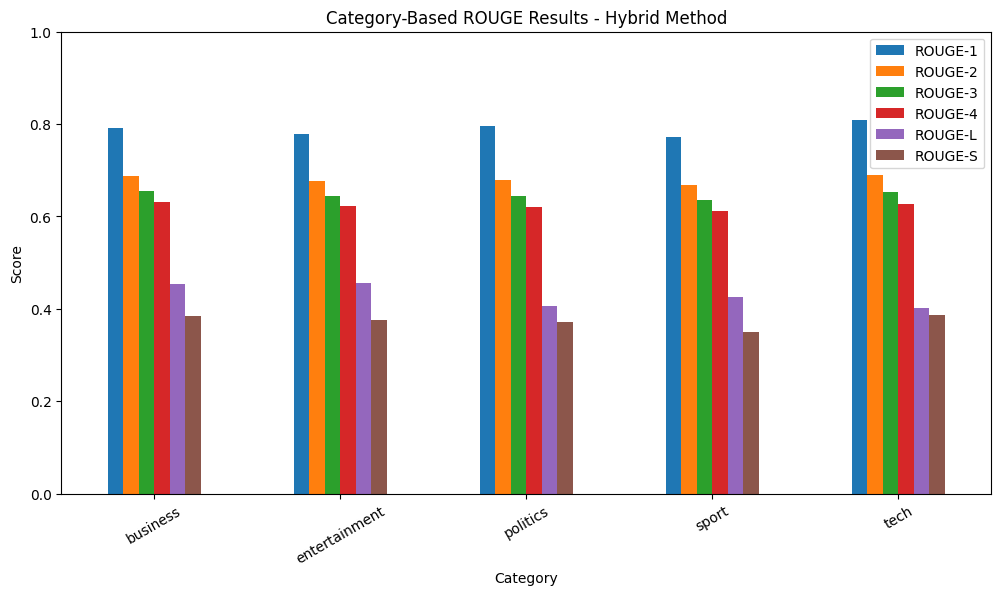

In [23]:
category_plot_df = category_results.set_index("Category")[["ROUGE-1", "ROUGE-2", "ROUGE-3", "ROUGE-4", "ROUGE-L", "ROUGE-S"]]

category_plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Category-Based ROUGE Results - Hybrid Method")
plt.xlabel("Category")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc="upper right")
plt.show()

In [24]:
comparison_results["Average ROUGE"] = comparison_results[rouge_metrics].mean(axis=1)
best_row = comparison_results.sort_values("Average ROUGE", ascending=False).iloc[0]

print("Best Method:", best_row["Method"])
print("Average ROUGE:", round(best_row["Average ROUGE"], 4))

comparison_results[["Method", "Average ROUGE"] + rouge_metrics]

Best Method: Hybrid
Average ROUGE: 0.5939


,Method,Average ROUGE,ROUGE-1,ROUGE-2,ROUGE-3,ROUGE-4,ROUGE-L,ROUGE-S
0,Frequency-Based,0.403547,0.496809,0.423666,0.403418,0.389631,0.428066,0.279692
1,TF-IDF,0.332579,0.444002,0.337891,0.315762,0.304418,0.370375,0.223025
2,Hybrid,0.593909,0.791806,0.684425,0.650591,0.627187,0.433448,0.375995


In [25]:
comparison_results.to_csv("method_comparison_results.csv", index=False)
category_results.to_csv("category_based_results.csv", index=False)

print("Saved files:")
print("method_comparison_results.csv")
print("category_based_results.csv")

Saved files:
method_comparison_results.csv
category_based_results.csv
